---
title: EDA II
---

::: {note} Learning Outcomes
* Overlay a LOWESS curve on a scatter plot with `sns.regplot(..., lowess=True)` and explain what the curve summarizes
* Size the points of a scatter plot by a third variable with `sns.scatterplot(..., size=...)`, and justify which variable to use
* Derive a count from a rate and a total with `.with_columns()` and `.cast()`, and name the assumptions that could make it wrong
* Describe the tidy table a plot needs: one row per plotted point, one column per feature
* Phrase a grouping question as "For each unique value of …, do …" and trace it through split, apply, and combine
:::

In this chapter, we will ask whether other characteristics of a school are related to its application rate. We start with one characteristic, the share of a school's students who qualify for free or reduced-price meals, and look at its relationship with the application rate in three ways: as a scatter plot with a smoothing curve, as a scatter plot whose points are sized by school, and as a four-point summary. Along the way, we will work out what table a summary plot needs, and meet the idea behind grouping, which the next chapter turns into code.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("colorblind")
pl.Config.set_fmt_str_lengths(40);

## Where We Left Off

In EDA I, a manager asked us to identify five California public high schools that defy typical patterns of application, admission, and/or attendance. We sorted the schools by their application rate, the number of students who applied to UC Berkeley divided by the number of 12th graders, and got a first answer. That answer left a lot uncovered. It says nothing about low application rates, or about admission and attendance, and we never defined what a "typical pattern" is. The schools at the top also came with explanations of their own: one was very small, and another was a specialized academy. Turning a fuzzy instruction like "defy typical patterns" into a concrete goal or metric is one of the key tasks of a data scientist, and we are not finished with it.

EDA I sorted the questions we can ask about this dataset into four kinds. Do we trust the data? Which schools have the highest rates? How much do the rates vary across schools? Are other characteristics of a school related to its rates? The first three are questions of context, extremes, and distributions, and EDA I worked through each of them. This chapter starts on the fourth, **correlation**. We use the word informally, to mean any relationship between two variables; later chapters measure it with a number.

EDA I ended by asking why application rates vary so much from school to school. The decision to apply is complex, and money, distance, academic resources, and individual and family priorities all play a part. Our starting point is one that the data can speak to. How do application rates relate to the share of a school's students who qualify for free or reduced-price meals?

### Rebuilding the Data

We begin by rebuilding the table that EDA I ended with. The file `pivoted-ucb-data-w-everything.csv` holds the UC admissions counts joined with data from the California Department of Education, including enrollment, charter status, distance to UC Berkeley, and the free/reduced-price meal share. As in EDA I, we add each school's application rate as a new column, then keep the schools whose rate is at most 1. That drops the handful of schools with impossible rates above 1, and the schools with no 12th-grade count, whose rate is `null`. Each step returns a new `DataFrame`, which we assign back to the name `admissions`.

**English:** Load the admissions data joined with the expanded school data, add a column with each school's application rate, and keep the rows where the application rate is at most 1.

In [2]:
admissions = pl.read_csv("data/pivoted-ucb-data-w-everything.csv")
admissions = admissions.with_columns(app_rate=pl.col("applied") / pl.col("grade_12"))
admissions = admissions.filter(pl.col("app_rate") <= 1)
admissions

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639,0.153425
…,…,…,…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,"""N""",0.180556,371.43283,0.210269
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,"""N""",0.479354,148.850295,0.052632
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,"""N""",0.460692,268.05834,0.057554


**SQL:**

```sql
SELECT *, applied / grade_12 AS app_rate
FROM admissions
WHERE applied / grade_12 <= 1
```

In standard SQL, `WHERE` is evaluated before `SELECT`, so many databases will not let it use the name `app_rate`. DuckDB does allow it, but we repeat the division so the query does not rely on a feature those databases lack. In some databases, such as SQLite, dividing two integers drops the remainder, so there you would write `applied * 1.0 / grade_12`. The `admissions` in the `FROM` clause is the table as it is stored in the database. A query returns a new table and leaves the stored one unchanged, so every later query in this chapter repeats `WHERE applied / grade_12 <= 1` in order to work with the same schools as the Polars code.

The preview reports 1,229 rows and 12 columns: the 11 columns of the file, plus `app_rate` at the end. The column this chapter leans on is `pct_free_reduced`, the fraction of a school's students who are eligible for free or reduced-price meals. EDA I showed where the California Department of Education publishes it. Eligibility depends on family income, so the column serves as a proxy for the average socioeconomic status of a school's students. Before plotting it, we summarize it.

**English:** Compute summary statistics for `pct_free_reduced`.

In [3]:
admissions.select("pct_free_reduced").describe()

statistic,pct_free_reduced
str,f64
"""count""",1173.0
"""null_count""",56.0
"""mean""",0.539032
"""std""",0.238133
"""min""",0.034247
"""25%""",0.340791
"""50%""",0.562603
"""75%""",0.734127
"""max""",0.985318


As EDA I noted, `.describe()` has no concise SQL equivalent.

The `count` row is 1,173 and the `null_count` row is 56, so 56 of the 1,229 schools have no free/reduced-price meal share. The known shares run from about 0.03 to 0.99, nearly the whole range from 0 to 1, and half of the known shares are above 0.56.

## Application Rate and Free/Reduced-Price Meals

A scatter plot puts one point on the page for each school, here with `pct_free_reduced` on the x-axis and `app_rate` on the y-axis. With more than a thousand points, the overall trend is hard to see by eye, so we draw a **smoothing curve** through the cloud that follows the typical `app_rate` at each value of `pct_free_reduced`. The curve we use is called LOWESS, short for *locally weighted scatterplot smoothing*.

Seaborn's `sns.regplot` draws a scatter plot with a fitted curve on top, and `lowess=True` makes that curve a LOWESS curve. Its `line_kws` argument ("line keywords") is a dictionary of formatting options for the curve, which here colors it red. Like every Seaborn function we have used, it takes the `DataFrame` first and then the names of the columns to plot. Two functions from `matplotlib`, `plt.xlabel` and `plt.ylabel`, set the axis labels.

**English:** Make a scatter plot with `pct_free_reduced` on the x-axis and `app_rate` on the y-axis, and add a red LOWESS curve.

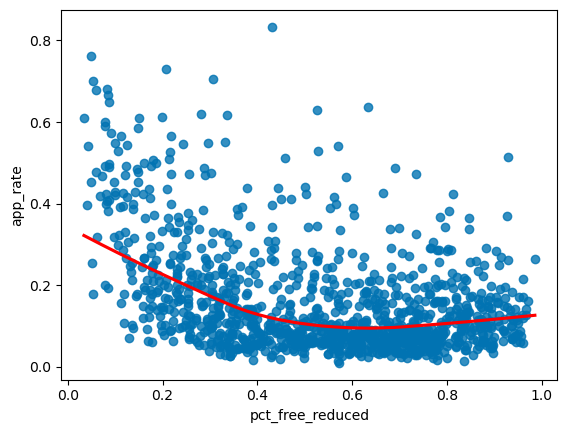

In [4]:
#| fig-alt: Scatter plot of app_rate against pct_free_reduced for 1,173 schools, with a red LOWESS curve. The points are densest at application rates below 0.2, and the highest rates, up to about 0.83, are mostly at low shares. The curve starts near 0.32 at the lowest shares, falls to just under 0.1 around a share of 0.6, and rises slightly to about 0.13 at the highest shares.
sns.regplot(admissions, x="pct_free_reduced", y="app_rate", lowess=True, line_kws={"color": "red"})
# regplot leaves the axis labels blank when it is given a Polars DataFrame, so we set them
plt.xlabel("pct_free_reduced")
plt.ylabel("app_rate");

There is no SQL for this step: SQL retrieves and summarizes tables, and it does not draw plots. Seaborn skipped the 56 schools with no `pct_free_reduced`, so the plot has 1,173 points, the `count` from the summary above.

The curve starts near 0.32 at the lowest free/reduced-price meal shares, falls steadily to just under 0.1 around a share of 0.6, and then rises slightly, to about 0.13 at the highest shares. Schools where fewer students qualify for free or reduced-price meals tend to have higher application rates. The points spread widely around the curve at every share, though, and most of the highest application rates are in the left half of the plot.

::: {tip} You are the driver, not the LLM
You decide what to plot and why: here, that the free/reduced-price meal share is worth comparing with the application rate, and that a smoothing curve will make the trend easier to see. Once you have made those decisions, an LLM can help you implement them, for example by finding the argument that colors a line. Do not let it do the thinking for you. Handing your thinking over to a tool is called *cognitive offloading*, and it has a cost: one 2025 study of students writing essays reported that "over four months, LLM users consistently underperformed at neural, linguistic, and behavioral levels" ([Kosmyna et al., 2025](https://arxiv.org/abs/2506.08872)).
:::

## What the Curve Averages

One way to think about LOWESS is to cut the x-axis into narrow bins, average the points within each bin, and connect those averages. That is an over-simplification, but it captures the idea: the height of the curve at each value of `pct_free_reduced` summarizes the points near that value.

::: {note} What LOWESS computes
Seaborn hands the calculation to the `lowess` function in the `statsmodels` library, with its default settings. To find the height of the curve at one x-value, it takes the two-thirds of all points whose x-values are closest, fits a straight line to them in which closer points count more, and reads off the height of that line. It then repeats the whole fit three more times, each time giving less weight to points that sit far from the current curve, so that a few extreme schools cannot drag the curve toward them.
:::

This raises a question. Should every point in the plot influence the shape of the curve equally? Right now each school counts the same, however many students it has. That is a choice, and to judge it we need to know how different the schools are in size.

**English:** Compute summary statistics for `grade_12`.

In [5]:
admissions.select("grade_12").describe()

statistic,grade_12
str,f64
"""count""",1229.0
"""null_count""",0.0
"""mean""",335.988609
"""std""",213.542671
"""min""",14.0
"""25%""",133.0
"""50%""",337.0
"""75%""",485.0
"""max""",1392.0


**SQL:** `.describe()` has no concise SQL equivalent, but the two extremes are one aggregate each:

```sql
SELECT MIN(grade_12), MAX(grade_12)
FROM admissions
WHERE applied / grade_12 <= 1
```

The smallest 12th-grade class has 14 students and the largest has 1,392, while the median school has 337. The largest school has about 100 times as many potential applicants as the smallest, yet in the scatter plot above both get a point of the same size.

Some schools have many more students than others, so arguably bigger schools should have more influence on the curve than smaller ones. Giving the points of a LOWESS curve different weights takes more specialized tools than Seaborn, but we can still make the plot show how big each school is. First, though, we have to choose: what should the weight of each data point be? Three candidates are the size of the 12th-grade class (`grade_12`), the total enrollment across all grades (`tot_enrolled`), and the number of students who applied (`applied`).

## Sizing Points by a Third Variable

`sns.scatterplot` draws a scatter plot, and its `size` argument names a column that sets the size of each point. Larger values get larger points, and Seaborn adds a legend showing which size stands for which value. One logical choice is to size each school by its number of potential applicants, the 12th-grade class.

**English:** Make a scatter plot with `pct_free_reduced` on the x-axis and `app_rate` on the y-axis, with points sized by 12th-grade enrollment.

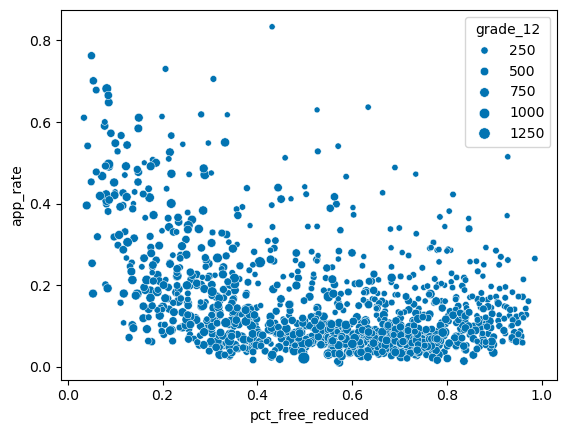

In [6]:
#| fig-alt: Scatter plot of app_rate against pct_free_reduced with points sized by grade_12, using Seaborn's default range of sizes. The legend lists sizes for 250, 500, 750, 1000 and 1250 12th graders. The smallest and largest points differ only modestly in size, so the plot looks much like an unsized scatter plot.
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="grade_12");

This time the axis labels appear without any help, and the legend lists five sizes, for 250 up to 1250 12th graders. The default sizes span a narrow range, though, so a school with 14 12th graders and a school with 1,392 look more alike than they should. The `sizes` argument sets the smallest and largest point sizes Seaborn may use. A formatting argument like this is something you look up rather than memorize: the [`sns.scatterplot` documentation](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) lists them all, and it can be helpful to experiment with different sizings.

**English:** Make the same scatter plot, with the point sizes spread over a wider range.

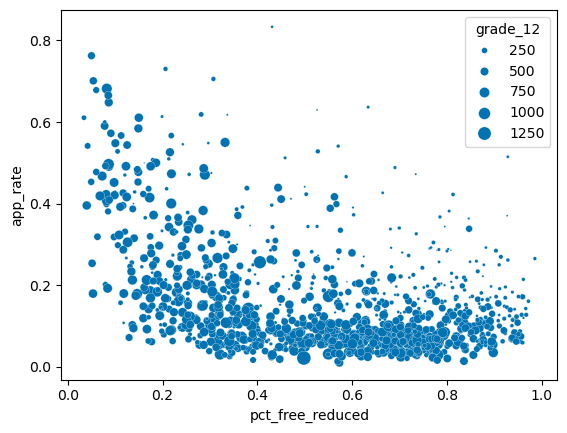

In [7]:
#| fig-alt: Scatter plot of app_rate against pct_free_reduced with points sized by grade_12 over a wide range of sizes. Many large points sit in the upper left, at low free/reduced-price meal shares and application rates between about 0.3 and 0.75. The points at high application rates on the right half of the plot are mostly tiny, and the dense band of points below 0.2 mixes sizes.
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="grade_12", sizes=(1, 100));

Now the size of a school is visible at a glance. Many large schools sit in the upper left, where free/reduced-price meal shares are low and application rates are high, while most of the points high up on the right are tiny.

### Four Ways to Size the Points

Each candidate weight gives a different plot. The figure below draws four of them side by side: plot A does not size the points at all, plot B sizes them by `grade_12` (the plot above), plot C by `tot_enrolled`, and plot D by `applied`. The code puts four panels in one figure with `plt.subplots(2, 2)` and tells Seaborn which panel to draw on with `ax=`, as in EDA I. In the same code, `figsize` sets the width and height of the figure in inches, `set_title` puts a title on each panel, and `plt.tight_layout()` keeps the panels from overlapping.

````{dropdown} Click to see the code
:open: false
```python
fig, ((ax_a, ax_b), (ax_c, ax_d)) = plt.subplots(2, 2, figsize=(12, 9))
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", ax=ax_a)
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="grade_12", sizes=(1, 100), ax=ax_b)
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="tot_enrolled", sizes=(1, 100), ax=ax_c)
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="applied", sizes=(1, 100), ax=ax_d)
ax_a.set_title("A: every school the same size")
ax_b.set_title("B: sized by grade_12")
ax_c.set_title("C: sized by tot_enrolled")
ax_d.set_title("D: sized by applied")
plt.tight_layout();
```
````

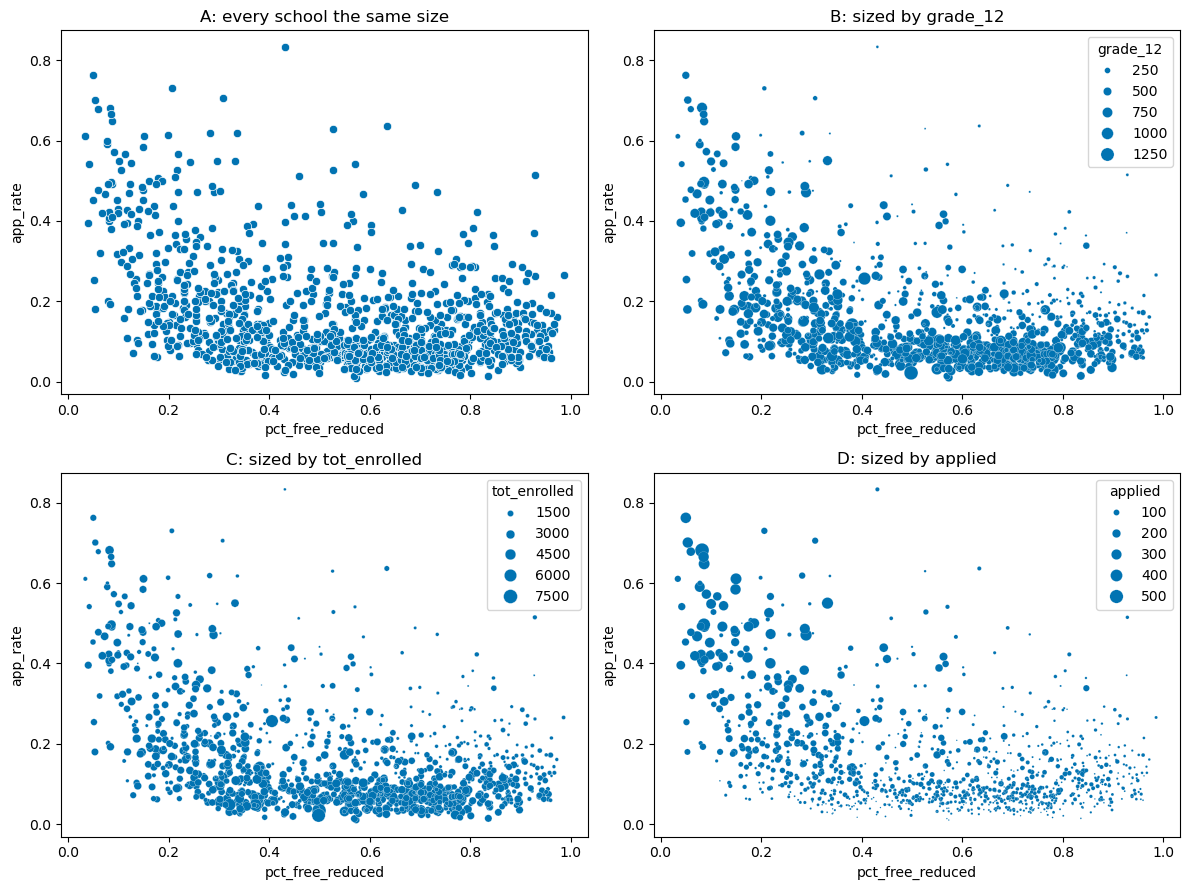

In [8]:
#| fig-alt: Four scatter plots of app_rate against pct_free_reduced in a two-by-two grid. Plot A, top left, draws every school as the same size of point. Plot B, top right, sizes points by grade_12, and plot C, bottom left, sizes them by tot_enrolled. B and C look nearly identical, with large points in the upper left and throughout the dense band of application rates below 0.2, while the points at high application rates on the right half are tiny. Plot D, bottom right, sizes points by applied, so the largest points are the high application rates at low shares, and almost every point below an application rate of 0.1 is tiny.
fig, ((ax_a, ax_b), (ax_c, ax_d)) = plt.subplots(2, 2, figsize=(12, 9))
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", ax=ax_a)
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="grade_12", sizes=(1, 100), ax=ax_b)
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="tot_enrolled", sizes=(1, 100), ax=ax_c)
sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="applied", sizes=(1, 100), ax=ax_d)
ax_a.set_title("A: every school the same size")
ax_b.set_title("B: sized by grade_12")
ax_c.set_title("C: sized by tot_enrolled")
ax_d.set_title("D: sized by applied")
plt.tight_layout();

What does each plot communicate?

* **Plot A is misleading.** Every school gets the same point, so the scattered schools toward the top right look as important as any other. Those schools are actually quite small.
* **Plots B and C are mostly identical.** Total enrollment counts every grade, not just the 12th, so the two differ only where a school's 12th-grade class is out of proportion to its enrollment, for example because of dropout rates or the number of grades the school offers.
* **Plot D is somewhat redundant with the y-axis.** `applied` is the numerator of `app_rate`, so schools with low application rates tend to have fewer students who applied, and small points. The sizes partly repeat what the y-axis already shows.

We can check the claim about plot A directly. If we keep only the schools with an application rate above 0.5 and sort them by free/reduced-price meal share, from highest to lowest, the schools at the top right of the plot come first. `pct_free_reduced` has missing values, so the sort passes `nulls_last=True`, as EDA I did to keep `null` values out of the top rows.

**English:** Keep the schools with an application rate above 0.5, sort them by free/reduced-price meal share in descending order with missing shares last, and show the first ten along with their sizes.

In [9]:
admissions.filter(pl.col("app_rate") > 0.5).sort(
    "pct_free_reduced", descending=True, nulls_last=True
).select("school", "city", "grade_12", "pct_free_reduced", "app_rate").head(10)

school,city,grade_12,pct_free_reduced,app_rate
str,str,i64,f64,f64
"""COLISEUM COLLEGE PREP ACADEMY""","""Oakland""",68,0.928205,0.514706
"""MAKING WAVES ACADEMY""","""Richmond""",77,0.633726,0.636364
"""DR RICHARD VLADOVIC HARBOR ACA""","""Wilmington""",98,0.57047,0.540816
"""KIPP KING COLLEGIATE HIGH SCH""","""San Lorenzo""",161,0.527536,0.52795
"""RENAISSANCE ARTS ACADEMY""","""Los Angeles""",27,0.525974,0.62963
"""MIDDLE COLLEGE HIGH SCHOOL""","""Stockton""",82,0.45858,0.512195
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""",60,0.431095,0.833333
"""EAST BAY INNOVATION ACADEMY""","""Oakland""",34,0.336653,0.617647
"""LOWELL HIGH SCHOOL""","""San Francisco""",660,0.33189,0.55


**SQL:**

```sql
SELECT school, city, grade_12, pct_free_reduced, applied / grade_12 AS app_rate
FROM admissions
WHERE applied / grade_12 <= 1
  AND applied / grade_12 > 0.5
ORDER BY pct_free_reduced DESC NULLS LAST
LIMIT 10
```

The first seven rows are the schools with a share above 0.4, and none of them has more than 161 12th graders, less than half the median of 337. RENAISSANCE ARTS ACADEMY has 27, MIDDLE COLLEGE HIGH SCHOOL in San Pablo has 60, and MAKING WAVES ACADEMY has 77. In plot A, each of them gets the same point as a school with more than a thousand 12th graders. A large school does not appear until the share drops to about 0.33, where LOWELL HIGH SCHOOL has 660.

### Take a Stand

Which plot is better? That depends on what you are trying to communicate. Plot B shows where the possible applicants are: every 12th grader counts, whether or not they applied. Plot D shows where most of the actual applicants come from. Both are reasonable, and there is no correct answer here. The decision is yours to make as the storyteller.

### Are You Picking the Same Five Schools?

Recall the task: identify five California public high schools that defy typical patterns of application, admission, and/or attendance. In plot A, the eye goes to the isolated points at the top right, which turn out to be small schools. In plots B and D, it goes to the large points in the upper left, big schools with low free/reduced-price meal shares and high application rates. Sizing the points changes which schools look unusual, and so it can change which five we pick. If we are trying to affect the most students, perhaps we should stick to larger schools?

## Counting the Students Behind a Rate

Sizing the points by `grade_12` weights each school by all of its 12th graders. If our interest is in students from lower-income families, a more targeted weight would be the number of 12th graders at each school who receive free or reduced-price meals. The data does not contain that number, but it contains two pieces we can combine to estimate it: the share of students who qualify, and the size of the 12th-grade class. Before reading on, try writing Polars code that adds this column. Could your calculation be wrong? If so, how and why?

Multiplying two columns works the same way as dividing them did in EDA I: `pl.col("pct_free_reduced") * pl.col("grade_12")` multiplies the two values in each row. The product is a float, such as 332.4, but a number of students should be a whole number. The `.cast()` method converts a column to a different data type. Passing Python's `int` converts to Polars' 64-bit integer type, which the preview labels `i64`, and converting a float to an integer this way drops the fractional part rather than rounding.

**English:** Add a column with the estimated number of 12th graders at each school who qualify for free or reduced-price meals.

In [10]:
admissions = admissions.with_columns(
    num_frl_12th=(pl.col("pct_free_reduced") * pl.col("grade_12")).cast(int)
)
admissions.select("school", "pct_free_reduced", "grade_12", "num_frl_12th")

school,pct_free_reduced,grade_12,num_frl_12th
str,f64,i64,i64
"""A B MILLER HIGH SCHOOL""",0.685365,485,332
"""ABLE CHARTER""",0.678421,73,49
"""ABRAHAM LINCOLN HIGH SCHOOL""",0.832272,242,201
"""ABRAHAM LINCOLN HIGH SCHOOL""",0.450172,489,220
"""ABRAHAM LINCOLN HIGH SCHOOL""",0.469298,365,171
…,…,…,…
"""YORBA LINDA HIGH SCHOOL""",0.180556,409,73
"""YOSEMITE HIGH SCHOOL""",0.479354,133,63
"""YREKA HIGH SCHOOL""",0.460692,139,64


**SQL:**

```sql
SELECT school, pct_free_reduced, grade_12,
       CAST(TRUNC(pct_free_reduced * grade_12) AS INTEGER) AS num_frl_12th
FROM admissions
WHERE applied / grade_12 <= 1
```

In DuckDB, `CAST(... AS INTEGER)` rounds to the nearest integer, so the query applies `TRUNC` first to drop the fractional part, which makes it agree with Polars.

A B MILLER HIGH SCHOOL, in the first row, has a share of 0.685365 and 485 12th graders. Their product is about 332.4, and the cast keeps 332. For ABLE CHARTER, 0.678421 × 73 is about 49.5, and the cast gives 49, where rounding would have given 50.

Could this calculation be wrong? It could, in at least four ways.

1. **It assumes that 12th graders qualify at the school-wide rate.** `pct_free_reduced` describes all of a school's students, and the share among its 12th graders may be higher or lower.
2. **It truncates rather than rounds**, so each count can fall almost one student short of the product.
3. **It inherits missing values.** The 56 schools with no `pct_free_reduced` get no count either, because any arithmetic involving `null` gives `null`.
4. **It treats qualifying as receiving.** `pct_free_reduced` is the share of students who qualify, and not every student who qualifies signs up for the meals. The column estimates how many 12th graders qualify, not how many receive the meals.

### A New Answer

If we want to reach the most students from lower-income families, we can rank the schools by this new count. The column has `null` values, so we sort with `nulls_last=True`, as in EDA I. Polars puts nulls first when it sorts, and without it the 56 schools with no count would fill the top of the table.

**English:** Sort the schools by the estimated number of 12th graders who qualify for free or reduced-price meals, in descending order, with missing counts last.

In [11]:
admissions.sort("num_frl_12th", descending=True, nulls_last=True).select(
    "school", "is_charter", "grade_12", "pct_free_reduced", "num_frl_12th", "app_rate"
)

school,is_charter,grade_12,pct_free_reduced,num_frl_12th,app_rate
str,str,i64,f64,i64,f64
"""PARAMOUNT HIGH SCHOOL""","""N""",958,0.791937,758,0.078288
"""VISIONS IN EDUCATION""","""Y""",1392,0.498074,693,0.021552
"""SANTA MARIA HIGH SCHOOL""","""N""",825,0.795498,656,0.084848
"""BAKERSFIELD HIGH SCHOOL""","""N""",823,0.781415,643,0.029162
"""ARVIN HIGH SCHOOL""","""N""",713,0.896628,639,0.054698
…,…,…,…,…,…
"""TECHNOLOGY HIGH SCHOOL""","""N""",75,null,null,0.253333
"""TORRES HS PERFORMING ARTS ACADEMY""","""N""",83,null,null,0.072289
"""TUSTIN CONNECT""","""N""",64,null,null,0.109375


**SQL:** `ORDER BY` can use the name `num_frl_12th`, because it is evaluated after `SELECT`.

```sql
SELECT school, is_charter, grade_12, pct_free_reduced,
       CAST(TRUNC(pct_free_reduced * grade_12) AS INTEGER) AS num_frl_12th,
       applied / grade_12 AS app_rate
FROM admissions
WHERE applied / grade_12 <= 1
ORDER BY num_frl_12th DESC NULLS LAST
```

PARAMOUNT HIGH SCHOOL leads with an estimated 758 12th graders who qualify for free or reduced-price meals, followed by VISIONS IN EDUCATION with 693. Both are large schools with low application rates: about 0.078 at PARAMOUNT, and about 0.022 at VISIONS IN EDUCATION, a charter school whose 1,392 12th graders make up the largest 12th-grade class in the data. The other three schools in the top five also have application rates below 0.09. At the bottom of the table, the last five rows have a `null` count, sent there by `nulls_last=True`.

## Are We Done?

We have a new answer: large schools where many students qualify for free or reduced-price meals but few apply to UC Berkeley. It is still not the best we can do. We have not defined "typical patterns", so we cannot yet say which schools defy them, and we have not looked at admission or attendance at all. Before picking five schools, we should spend some time understanding the broad patterns in all three outcomes.

## Summarizing Patterns

Which is better: a plot that shows every school, or one that shows only the overall pattern? Depending on the audience, we may or may not want to show every data point. The sized scatter plots of the previous sections show all 1,173 schools with a known meal share. A summary plot can show just a handful of points instead: here, one application rate for each quarter of the schools, from the quarter with the lowest free/reduced-price meal shares to the quarter with the highest.

The code for this plot uses verbs that the next chapter teaches step by step. Here is what each one does:

* `.filter(pl.col("pct_free_reduced").is_not_null())` keeps the schools with a known share, using the `.is_not_null()` check that EDA I mentioned.
* `qcut(4, labels=[...])` splits the schools into four equal-sized groups by `pct_free_reduced`, and gives each group a label.
* `.cast(pl.String)` turns those labels into plain text for Seaborn.
* `.group_by("frl_percentile").agg(...)` totals `applied` and `grade_12` within each group, and divides one total by the other.
* `.sort("frl_percentile")` puts the four groups in order, and `sns.lineplot` draws the four points and joins them with lines.

````{dropdown} Click to see the code
:open: false
```python
app_by_frl = (
    admissions
    .filter(pl.col("pct_free_reduced").is_not_null())
    .with_columns(
        frl_percentile=pl.col("pct_free_reduced")
        .qcut(4, labels=["0-25", "25-50", "50-75", "75-100"])
        .cast(pl.String)
    )
    .group_by("frl_percentile")
    .agg(avg_app_rate=pl.col("applied").sum() / pl.col("grade_12").sum())
    .sort("frl_percentile")
)
sns.lineplot(app_by_frl, x="frl_percentile", y="avg_app_rate");
```
````

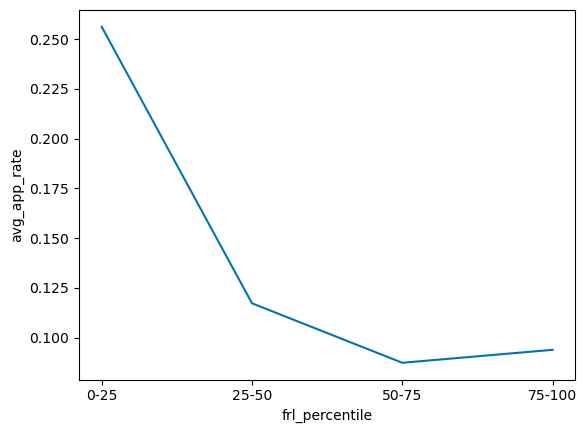

In [12]:
#| fig-alt: Line plot of avg_app_rate for four frl_percentile bins, 0-25, 25-50, 50-75 and 75-100. The line falls steeply from about 0.26 in the 0-25 bin to about 0.12 in the 25-50 bin, reaches its lowest point, just under 0.09, in the 50-75 bin, and rises slightly in the 75-100 bin.
app_by_frl = (
    admissions
    .filter(pl.col("pct_free_reduced").is_not_null())
    .with_columns(
        frl_percentile=pl.col("pct_free_reduced")
        .qcut(4, labels=["0-25", "25-50", "50-75", "75-100"])
        .cast(pl.String)
    )
    .group_by("frl_percentile")
    .agg(avg_app_rate=pl.col("applied").sum() / pl.col("grade_12").sum())
    .sort("frl_percentile")
)
sns.lineplot(app_by_frl, x="frl_percentile", y="avg_app_rate");

::: {note}
The `0-25` bin holds the 25% of schools with the lowest values of `pct_free_reduced`, among the 1,173 with a known share. It is not every school with a `pct_free_reduced` between 0 and 0.25. The 25% row of the summary at the start of the chapter is 0.340791, so the lowest bin reaches up to a share of about 0.34.
:::

The summary plot tells the same story as the LOWESS curve with far less detail. The application rate falls steeply from about 0.26 in the lowest quarter to about 0.12 in the next, reaches its lowest point, just under 0.09, in the third, and rises slightly in the highest quarter.

Another option keeps every school while letting the trend stand out: make the points nearly transparent, and draw a bold curve on top of them. The `scatter_kws` argument does for the points what `line_kws` does for the curve. An `alpha` of 0.1 makes each point 90% transparent, so only places where many points overlap look dark, and a `linewidth` of 3 thickens the curve.

**English:** Make a scatter plot with `pct_free_reduced` on the x-axis and `app_rate` on the y-axis, with nearly transparent points and a bold red LOWESS curve.

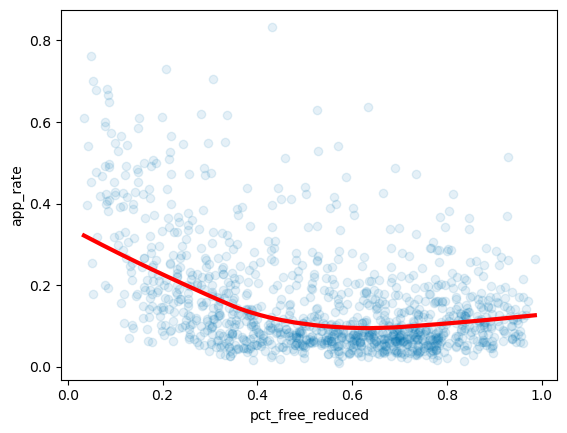

In [13]:
#| fig-alt: Scatter plot of app_rate against pct_free_reduced with nearly transparent points and a thick red LOWESS curve. The points are darkest where they overlap, in a band of application rates below about 0.2 that stretches across shares from about 0.2 to 1. The curve falls from about 0.32 at the lowest shares to just under 0.1 around 0.6, then rises slightly to about 0.13.
sns.regplot(
    admissions, x="pct_free_reduced", y="app_rate", lowess=True,
    scatter_kws={"alpha": 0.1}, line_kws={"color": "red", "linewidth": 3},
)
plt.xlabel("pct_free_reduced")
plt.ylabel("app_rate");

### Tidy Data

What data do we need to make the summary plot? In **tidy data**, each row is one observation and each column is one variable. For a plot, the observations are its points, so each row represents one data point in the plot. The summary plot has 4 points, so its table needs 4 rows. Each point has 2 features, its `frl_percentile` bin and its `avg_app_rate`, so the table needs 2 columns.

`sns.scatterplot` draws one point for each row of the table it is given. `sns.lineplot` draws one point for each x-value: when several rows share an x-value, it averages them, giving each row the same weight, and shades a confidence band around the average. Handed every school with its bin, it would give each school an equal say in its bin's point. We want each school to count in proportion to its 12th-grade class, so to control exactly what each point means, we build a table with one row per point before making the call. The folded cell above built exactly this table and named it `app_by_frl`.

In [14]:
app_by_frl

frl_percentile,avg_app_rate
str,f64
"""0-25""",0.256207
"""25-50""",0.117248
"""50-75""",0.087358
"""75-100""",0.093879


Each `avg_app_rate` is the total number of applicants in a bin divided by the total number of 12th graders in that bin: 0.256207 for the lowest quarter, then 0.117248, 0.087358, and 0.093879. That makes it an average in which each school counts in proportion to its 12th-grade class, the kind of weighting we asked about for the LOWESS curve.

The folded cell generated this table, but with verbs we have only previewed. How do we generate this data ourselves? That is the question the next chapter answers.

## Anatomy of a Seaborn Call

Every Seaborn call in this chapter has the same four parts. Here they are in the sized scatter plot from earlier, `sns.scatterplot(admissions, x="pct_free_reduced", y="app_rate", size="grade_12", sizes=(1, 100))`:

| Part | In the sized scatter plot | What goes there |
|---|---|---|
| Plotting function | `sns.scatterplot` | The kind of plot: `scatterplot`, `lineplot`, `histplot`, `boxplot`, and so on |
| `DataFrame` | `admissions` | The table that holds the data |
| Column mappings | `x="pct_free_reduced"`, `y="app_rate"`, `size="grade_12"` | The column behind each visual property of a point: its position (`x`, `y`), its `size`, its color (`hue`), and so on |
| Formatting arguments | `sizes=(1, 100)` | Anything else about how the plot looks |

The first three parts are decisions about what the plot shows, and they deserve thought. The formatting arguments are look-it-up territory: the documentation, or an LLM, can tell you what they are called.

## Grouping: Split, Apply, Combine

Here are the fundamental operations we have used so far:

* View a preview of a `DataFrame`.
* Select specific columns.
* Create new columns.
* Filter to specific rows.
* Order the data by the values in a column.
* Calculate summary statistics for one or more columns.
* Visualize one-dimensional data with a boxplot or histogram.
* Visualize two-dimensional data with a scatter plot or line plot.

One more belongs on the list: group the rows by some variable, and then do something to each group, most often aggregate it. In English, a grouping operation reads "For each unique value of COLUMN(S), do SOMETHING." The summary plot came from one: for each `frl_percentile` bin, compute the application rate. Grouping and visualizing together make up the majority of EDA with tabular data.

### Counting Rows in Each Group

Grouping follows a pattern called **split-apply-combine**. Consider "For each unique value of `city`, count the number of rows." First we split the table into one group for each city. Then we apply the count to each group separately. Finally, we combine the counts into a new table with one row per city.

```{image} images/split_apply_combine_count.png
:alt: Split-apply-combine diagram. A City column with rows A, A, A, B, B, B, C, C is split into three groups by city. Counting the rows in each group gives A 3, B 3, C 2, and these combine into one table with columns City and # Rows.
:width: 600
```

You have already run this operation: `value_counts`, from EDA I, is split-apply-combine for counting rows.

**English:** For each unique value of `city`, count the number of rows, and show the five cities with the most schools.

In [15]:
admissions["city"].value_counts(sort=True).head(5)

city,count
str,u32
"""Los Angeles""",100
"""San Diego""",41
"""San Jose""",31
"""Oakland""",28
"""Sacramento""",27


**SQL:** `GROUP BY city` is the split, `COUNT(*)` is the apply, and the result table is the combine.

```sql
SELECT city, COUNT(*) AS count
FROM admissions
WHERE applied / grade_12 <= 1
GROUP BY city
ORDER BY count DESC
LIMIT 5
```

Los Angeles has 100 schools, followed by San Diego with 41, San Jose with 31, Oakland with 28, and Sacramento with 27. Two of these counts are smaller than in EDA I, where Los Angeles had 112 and Sacramento 28, because this `admissions` holds only the 1,229 schools with an application rate of at most 1, not all 1,268 schools in the file.

### Averaging Within Each Group

The apply step can be any computation on a group. "For each unique value of `city`, compute the mean number of students enrolled across its schools" splits the table the same way, then applies a mean of the enrollment to each group instead of a count.

```{image} images/split_apply_combine_mean.png
:alt: Split-apply-combine diagram. A table of City and Enroll values is split into groups A (25, 30, 35), B (30, 50, 40) and C (20, 30). Averaging each group gives mean enrollments of 30, 40 and 25, which combine into one City and Mean Enroll table.
:width: 600
```

A city with only one school forms a group of one, and its mean is simply that school's enrollment: a city with one big high school gets a big mean.

In the next chapter, we will write "For each…" statements like these in Polars, and use them to build the four-row table behind the summary plot.